# DATA EXPLORATION IN PANDA

### Workforce Analytics Data Cleaning And Employee Performance Insights

Import the pandas Libary and find and load your CSV file into the dataframe

In [121]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\Downloads\Dirty Data.csv")



# Data Exploration

Exploration
Before cleaning, you need to first explore your data to see what dataset you are working with.

1. Use df.head() to load the first five cell
2. Use df.tail() to load the last five cell
3. Use df.shape to check the number of columns and rows
4. Use df.info() to check the column names, data types, and null count

In [122]:
df.head()


,employee_id,name,age,salary,department,email,join_date,city,performance_score
0,137,Jacob Jackson,41,43251.2,sales,hlewis@harris.com,2021-03-12,Utrecht,2.59
1,629,ALEXANDRA HENRY,64,55835.87,HR,laurawilson@hotmail.com,2017-02-18,Rotterdam,1.37
2,185,Aaron Hinton,39,51648.06,Sales,pachecorichard@yahoo.com,2022-03-30,amsterdam,1.47
3,32,christopher parker,34,82784.17,IT,jimmyyoung[at]burton.com,2024-01-21,Utrecht,3.91
4,678,Lori Manning,55,81284.06,HR,adkinsgeorge@moore-hicks.biz,2017-09-09,Rotterdam,2.58


In [123]:
df.tail()

,employee_id,name,age,salary,department,email,join_date,city,performance_score
1035,88,Nathaniel Carter,59,59931.27,HR,piercebryan[at]yahoo.com,NaN,Amsterdam,1.39
1036,331,Brian Clark,61,54816.3,HR,vanessarodgers@gmail.com,2019-11-09,Amsterdam,2.71
1037,467,Sean Atkins,29,64212.5,Marketing,kdecker@clark.biz,2025-11-27,Utrecht,-1.00
1038,122,Richard Cook,42,41359.19,Finance,jvega@yahoo.com,2026-02-11,The Hague,1.55
1039,861,Aaron Hill III,39,58043.85,marketing,martin44@baldwin-flynn.com,2023-06-10,Utrecht,4.04


In [124]:
df.shape

(1040, 9)

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        1010 non-null   object 
 1   name               1040 non-null   object 
 2   age                1026 non-null   object 
 3   salary             1040 non-null   object 
 4   department         1040 non-null   object 
 5   email              1040 non-null   object 
 6   join_date          1018 non-null   object 
 7   city               1040 non-null   object 
 8   performance_score  1027 non-null   float64
dtypes: float64(1), object(8)
memory usage: 73.3+ KB


5. Use df.columns to explore all columns

In [126]:
df.columns

Index(['employee_id', 'name', 'age', 'salary', 'department', 'email',
       'join_date', 'city', 'performance_score'],
      dtype='object')

6. Use df.dtypes to check the data type for each column

In [127]:
df.dtypes


employee_id           object
name                  object
age                   object
salary                object
department            object
email                 object
join_date             object
city                  object
performance_score    float64
dtype: object

7. Use df.describe to run summary statistics for numeric columns

In [128]:
df.describe()

,performance_score
count,1027.000000
mean,2.927809
std,1.432768
min,-1.000000
25%,1.890000
50%,2.920000
75%,3.935000
max,10.000000


8. Use df.isnull().sum() to count missing values per column

In [129]:
df.isnull().sum()

employee_id          30
name                  0
age                  14
salary                0
department            0
email                 0
join_date            22
city                  0
performance_score    13
dtype: int64

9. Use df.duplicated().sum() to count duplicate rows

In [130]:
df.duplicated().sum()


np.int64(40)

# Data Cleaning Process

### 1. Removing Duplicates
During exploration, I discovered that there was duplicate records in the dataset. Duplicates can distort results and leads to irregular and inaccurate conclusion. The duplicates were identified using: df.duplicated().sum()

In [131]:
df.duplicated().sum()

np.int64(40)

So with the code above, it shows that we have 40 duplicates. To resolve this issue, we'll be using: df.drop_duplicates(inplace=True) to drop the duplicatev and this will help to prevent double counting and inprove the quality of the data.

In [132]:
df.drop_duplicates(inplace=True)

In [133]:
df.duplicated().sum()

np.int64(0)

### 2. Handling Missing Values
After resolving the duplicates, I discovered that some columns contained missing(Null/NaN) values, which can affect the accuracy of the analysis and lead to errors during calculations. As seen in the exploration section, I identified the missing values using: df.isnull().sum()

In [134]:
df.isnull().sum()

employee_id          29
name                  0
age                  14
salary                0
department            0
email                 0
join_date            21
city                  0
performance_score    13
dtype: int64

To handle this missing values, we have to treat column specifically

#### 1. Employee_id
Since employee IDs are unique identifiers, they cannot be filled with random numbers or averages. Therefore, rows with missing values are going to be removed because missing employee IDs make it impossible to uniquely identify records. I remove the missing IDs with: df.dropna(subset=['employee_id'], inplace=True)

In [138]:
df.dropna(subset=['employee_id'], inplace=True)

In [140]:
df['employee_id'].isnull().sum()

np.int64(0)

#### 2. Age
The best way to handle missing age values is to replace them with the median age, because the median is less affected by extreme values and provides a more reliable estimate.
However, before doing that, we need to convert the age from an object, as seen in the exploration, to a numeric value to handle the missing value.

In [141]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')

The code above converts the age column from an object to a numerical value, and 'coerce' tells panda that if it cannot convert it, peplace it with NaN

In [142]:
df['age'].dtype

dtype('float64')

To also eliminate outliers in the dataset, you need to identify them and convert them to missing values/NaN. But we need to first import numpy

In [143]:
import numpy as np

In [144]:
df[(df['age'] < 18) | (df['age'] > 65)]

,employee_id,name,age,salary,department,email,join_date,city,performance_score
19,630,Nathaniel Franklin,-5.0,71412.87,sales,jamescoleman@brown.com,2021-03-08,The Hague,1.44
36,440,Norma Lane,150.0,54166.78,IT,samanthamarquez@gmail.com,2018-02-20,Rotterdam,2.69
37,555,Jason Anderson,150.0,60064.04,Finance,tsalas@monroe-roberts.com,2016-07-14,Amsterdam,1.48
66,362,Joseph Hamilton,150.0,77991.08,sales,stephaniewalls@garcia.com,2020-03-15,Utrecht,3.36
95,55,Julie Garcia,150.0,70464.99,IT,michael43@berry.org,2025-07-28,The Hague,3.12
116,406,Alan Durham,-5.0,64342.75,HR,kimberly08@williams.com,2017-08-18,Utrecht,4.10
128,199,Monica George,150.0,55873.13,IT,john28@hotmail.com,2023-08-20,Rotterdam,3.72
192,957,Penny Obrien,150.0,60140.88,marketing,glenda52@powers-lopez.biz,2023-12-13,Rotterdam,4.24
292,434,Ruben Edwards,150.0,65763.13,IT,umayo@thomas.com,2024-11-17,amsterdam,4.73
308,267,Timothy Yates,-5.0,79486.17,sales,ashleyhall@kent.com,32-13-2020,The Hague,1.88


In [145]:
df.loc[(df['age'] < 18) | (df['age'] > 65), 'age'] = np.nan

After converting the missing value to NaN, calculate for median, after calculating for median, then replace the missing values with median.

In [146]:
median_age = df['age'].median()
print(median_age)

42.0


In [147]:
df['age'] = df['age'].fillna(median_age)

In [148]:
df['age'].isnull().sum()

np.int64(0)

#### 3. Join_Date
To correctly handle issue of missing value in the join_date column, I had to treat this differently not as a numeric value but rather a date field.
First of all, i had to convert the join_date column to date format because when exploring the column was an object meaning panda is treating it as a text and not a date.

In [149]:
df['join_date'] = pd.to_datetime(df['join_date'], errors='coerce')

This line of code converts the column to a date format, errors='coerce' tells panda that any invalid date should be registered as NaT, which is the equivalent of NaN.
Use fillna(df['join_date'].median()) to replace the missing values with the median of join_date

In [150]:
df['join_date'] = df['join_date'].fillna(df['join_date'].median())

In [151]:
df['join_date'].isnull().sum()

np.int64(0)

#### 4. Performance_scores
While exploring the dataset, I noticed that the perfomance_score contained missing values, non-numeric, invalid scores, and the type is reflecting object, meaning panda considers the column to be a text and not a numeric value.
so to fix this issue, i will convert from object to numerical value, replace invalid score with missing value, and finally fill the missing value with median

##### 1. Convert to Numeric Value

In [152]:
df['performance_score'] = pd.to_numeric(
    df['performance_score'],
    errors='coerce'
)

##### 2.Check for invalid scores

In [153]:
df[(df['performance_score'] < 1) | (df['performance_score'] > 5)]

,employee_id,name,age,salary,department,email,join_date,city,performance_score
13,762,Carolyn Miller,23.0,56830.15,Sales,flemingjames@hotmail.com,2022-06-21,eindhoven,-1.0
83,843,Lisa Davis,44.0,38159.17,IT,ekim@lopez.org,2020-10-28,Rotterdam,10.0
107,299,Adam Lewis,45.0,67192.93,Finance,stewartdave@alvarez.com,2026-02-01,amsterdam,-1.0
137,498,Linda Lopez,39.0,52144.92,Finance,patelcharles@hotmail.com,2019-01-01,Rotterdam,-1.0
194,715,Brandon Shannon,65.0,54435.48,Finance,lisasmith@curry.info,2018-03-17,Amsterdam,10.0
196,686,Trevor Reyes,45.0,65694.98,Finance,woodschad@gmail.com,2017-12-29,Utrecht,10.0
272,495,Rhonda Cruz,54.0,77846.86,Sales,sextongabriel@houston-patterson.com,2017-05-15,amsterdam,-1.0
385,1,DR. TODD LESTER,32.0,62450.71,Sales,omartin@french.com,2021-10-17,Amsterdam,10.0
419,165,Deborah Mendez,64.0,69450.64,Sales,michaelcollins@gmail.com,2021-07-21,Rotterdam,-1.0
466,984,Richard Carr DDS,65.0,54284.33,Sales,burnettmichael@yahoo.com,2020-11-17,Rotterdam,10.0


##### 3. Replace Invalid Scores with Missing Value

In [154]:
import numpy as np

df.loc[
    (df['performance_score'] < 1) |
    (df['performance_score'] > 5),
    'performance_score'
] = np.nan

##### 4. Fill Missing Value
Use median to fill missing value because it is less affected by outliers

In [155]:
df['performance_score'] = df['performance_score'].fillna(
    df['performance_score'].median()
)

In [156]:
df['performance_score'].isnull().sum()

np.int64(0)

#### 5. Salary
The salary column also contained non-numeric entries and extreme outliers. In order to clean, I will convert the column to a numeric data type using pd.to_numeric() with errors='coerce', which also transforms text values to missing values.


In [157]:
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')

Also I replaced the outliers with missing values

In [158]:
import numpy as np

df.loc[
    (df['salary'] < 0) |
    (df['salary'] > 200000),
    'salary'
] = np.nan

Then i replaced the missing values with the median of the salary using Fillna

In [159]:
df['salary'] = df['salary'].fillna(df['salary'].median())

Finally, I used df['salary'].describe() to check if the correction is implemented

In [160]:
df['salary'].describe()

count       971.000000
mean      55326.624181
std       14465.793712
min        6380.990000
25%       45640.305000
50%       55397.330000
75%       64595.765000
max      112790.970000
Name: salary, dtype: float64

In [161]:
df.reset_index(drop=True, inplace=True)

### 3. Capitalize The First Letter Of Names

While exploring the data, I noticed some inconsistencies in name arrangement, especially in capitalization. To address this issue, I used a for loop to avoid including columns that do not need cleaning.

In [163]:
cols = ['name', 'department', 'city']

for col in cols:
    df[col] = df[col].str.title()

### 4. Capitalize Column Names

df.columns = df.columns.str.title() to fix the capitalization in column names

In [164]:
df.columns = df.columns.str.title()

In [165]:
df.columns.tolist()

['Employee_Id',
 'Name',
 'Age',
 'Salary',
 'Department',
 'Email',
 'Join_Date',
 'City',
 'Performance_Score']

### 5. Strip Spaces
This helps to remove spaces from strings in the dataset.

#### Department

In [185]:
df['Department'].unique()

array(['Sales', 'Hr', 'It', 'Marketing ', 'Finance', 'Marketing'],
      dtype=object)

In [186]:
df['Department'] = df['Department'].str.strip().str.title()

In [187]:
df['Department'].unique()

array(['Sales', 'Hr', 'It', 'Marketing', 'Finance'], dtype=object)

#### City

In [188]:
df['City'].unique()

array(['Utrecht', 'Rotterdam', 'Amsterdam ', 'The Hague', 'Eindhoven',
       'Amsterdam'], dtype=object)

In [189]:
df['City'] = df['City'].str.strip().str.title()

In [190]:
df['City'].unique()

array(['Utrecht', 'Rotterdam', 'Amsterdam', 'The Hague', 'Eindhoven'],
      dtype=object)

## Verification

In [166]:
df.isnull().sum() 

Employee_Id          0
Name                 0
Age                  0
Salary               0
Department           0
Email                0
Join_Date            0
City                 0
Performance_Score    0
dtype: int64

In [167]:
df.duplicated().sum() 

np.int64(0)

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Employee_Id        971 non-null    object        
 1   Name               971 non-null    object        
 2   Age                971 non-null    float64       
 3   Salary             971 non-null    float64       
 4   Department         971 non-null    object        
 5   Email              971 non-null    object        
 6   Join_Date          971 non-null    datetime64[ns]
 7   City               971 non-null    object        
 8   Performance_Score  971 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 68.4+ KB


In [169]:
df.head()

,Employee_Id,Name,Age,Salary,Department,Email,Join_Date,City,Performance_Score
0,137,Jacob Jackson,41.0,43251.20,Sales,hlewis@harris.com,2021-03-12,Utrecht,2.59
1,629,Alexandra Henry,64.0,55835.87,Hr,laurawilson@hotmail.com,2017-02-18,Rotterdam,1.37
2,185,Aaron Hinton,39.0,51648.06,Sales,pachecorichard@yahoo.com,2022-03-30,Amsterdam,1.47
3,32,Christopher Parker,34.0,82784.17,It,jimmyyoung[at]burton.com,2024-01-21,Utrecht,3.91
4,678,Lori Manning,55.0,81284.06,Hr,adkinsgeorge@moore-hicks.biz,2017-09-09,Rotterdam,2.58


## AGGREGATION
After cleaning the dataset, I moved to aggregating the data using groupby. Aggregation helps to answer various business question in relation to the dataset.

#### Total Employees

In [174]:
df['Employee_Id'].nunique()

971

#### Average Salary

In [177]:
df['Salary'].mean()

np.float64(55326.62418125644)

#### Average Performance Score

In [176]:
df['Performance_Score'].mean()

np.float64(2.9252729145211127)

#### Employees by Department

In [192]:
df.groupby('Department').size()

Department
Finance      151
Hr           141
It           138
Marketing    249
Sales        292
dtype: int64

#### Average Salary By Department

In [193]:
df.groupby('Department')['Salary'].mean()

Department
Finance      53518.425563
Hr           53873.369149
It           57589.073696
Marketing    56245.322530
Sales        55110.778390
Name: Salary, dtype: float64

#### Average Performance by Depatment

In [194]:
df.groupby('Department')['Performance_Score'].mean()

Department
Finance      2.950795
Hr           2.808014
It           2.935725
Marketing    2.979197
Sales        2.917774
Name: Performance_Score, dtype: float64

#### Employees by City

In [195]:
df.groupby('City').size()

City
Amsterdam    348
Eindhoven    173
Rotterdam    153
The Hague    150
Utrecht      147
dtype: int64

#### Department Salary Statistics

In [196]:
df.groupby('Department')['Salary'].agg(
    ['count', 'mean', 'min', 'max']
)

,count,mean,min,max
Department,,,,
Finance,151,53518.425563,25604.95,87297.74
Hr,141,53873.369149,17925.33,87159.16
It,138,57589.073696,23141.56,101183.21
Marketing,249,56245.322530,14546.70,112790.97
Sales,292,55110.778390,6380.99,93600.40


All the above Aggregation helps to build a Dashboard, KPI, and also helps give insight into the business.

### Data Visualization

Using the informations from the aggregation and grouping, we use them to create a dashboard and KPI.

Import matplotlib, this is python libary for visualization, it helps to convert list of numbers in python into meaningful charts.

In [197]:
import matplotlib.pyplot as plt

#### 1. Employees by Department

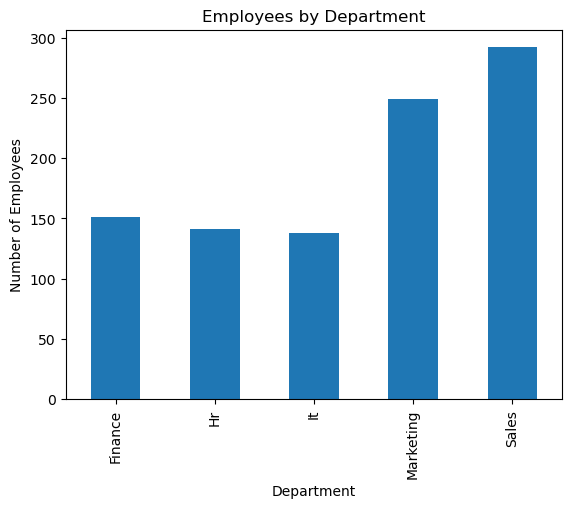

In [198]:
df.groupby('Department').size().plot(kind='bar')

plt.title('Employees by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')

plt.show()

### Insight
The sales department has the highest volume of employees, this suggest that there is a greater demand to upsell.

#### 2. Average Salary by Department

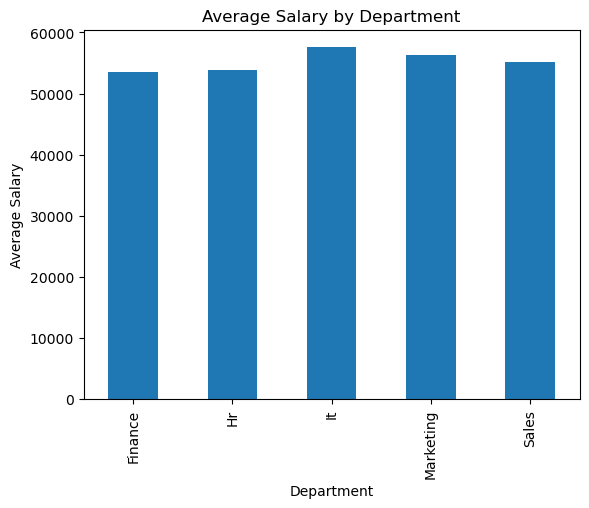

In [199]:
df.groupby('Department')['Salary'].mean().plot(kind='bar')

plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')

plt.show()

### Insight
The IT department has the highest average salary, suggesting a greater demand for technical skills.

#### 3. Average Performance by Department

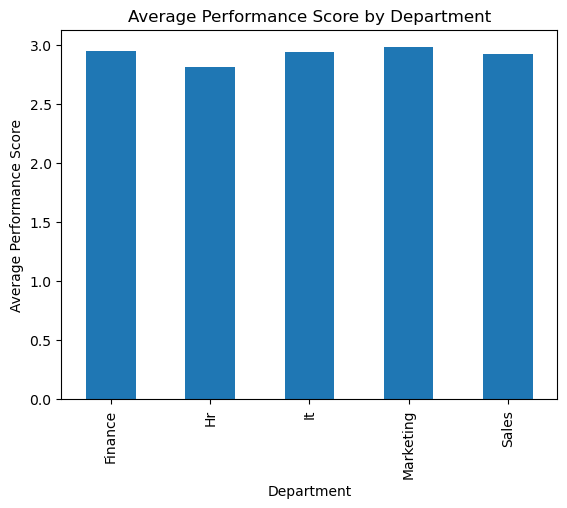

In [200]:
df.groupby('Department')['Performance_Score'].mean().plot(kind='bar')

plt.title('Average Performance Score by Department')
plt.xlabel('Department')
plt.ylabel('Average Performance Score')

plt.show()

### Insight
Finance has the highest average performance score, indicating stronger employee performance relative to other departments.

#### 4. Employees by City

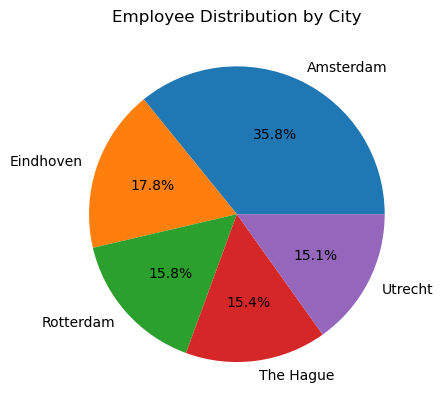

In [201]:
df.groupby('City').size().plot(kind='pie', autopct='%1.1f%%')

plt.ylabel('')
plt.title('Employee Distribution by City')

plt.show()

### Insight
Amsterdam has the highest distribution of employees, an indication that it is the company's largest operational location.

### Building KPI

KPI metrics helps to build the numbers that appear on the top of the dashboard.

In [202]:
total_employees = df['Employee_Id'].nunique()
avg_salary = df['Salary'].mean()
avg_performance = df['Performance_Score'].mean()
num_departments = df['Department'].nunique()

In [203]:
print("Total Employees:", total_employees)
print("Average Salary:", avg_salary)
print("Average Performance:", avg_performance)
print("Departments:", num_departments)

Total Employees: 971
Average Salary: 55326.62418125644
Average Performance: 2.9252729145211127
Departments: 5


## OVERALL INSIGHTS AND RECOMMENDATION

#### INSIGHTS
1. Amsterdam is the largest operational hub, accounting for 35.8% of all staff, significantly ahead of other cities.
2. Sales is the largest department (292 employees), followed by Marketing (249). HR, Finance, and IT are comparatively lean.
3. IT leads average salary (~$57,589), while Finance and HR trail slightly. Salary spread across departments is narrow, suggesting a flat pay structure.
4. Average performance (2.93/5) sits just below the midpoint, with Marketing scoring highest and HR the lowest, suggesting performance is moderate and inconsistent across teams.
5. Significant data quality issues were found: 40 duplicates, missing employee IDs, invalid ages (negatives and 150+), and malformed salary entries, indicating weak data governance.

#### RECOMMENDATIONS

1. Introduce succession planning to prepare for an aging workforce and reduce knowledge loss risk.
2. Strengthen entry-level hiring to balance experience with fresh talent across all departments.
3. Investigate the performance gap in HR. Consider targeted training programs or workload reviews to raise average scores.
4. Review staffing levels in Sales and Marketing relative to output. Large headcounts should correlate with stronger performance scores.
5. Assess whether the narrow salary band across departments is competitive, particularly for high-skill roles in IT and Finance.
5. Implement mandatory data validation rules at the point of entry, especially for employee IDs, dates of birth, and salary fields, to prevent recurring data quality issues.
6. Standardize department and city naming conventions (e.g., "sales" vs "Sales", "amsterdam" vs "Amsterdam") to ensure clean, consistent reporting going forward.
